# <center><u>Plotting Decision Boundaries</u></center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

In [2]:
df=pd.read_csv("../data/iris.csv")
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
from sklearn import preprocessing

In [4]:
le = preprocessing.LabelEncoder()

In [5]:
df['class']=le.fit_transform(df['Species'].values)

In [6]:
df[:5]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,class
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['PetalLengthCm','PetalWidthCm']], df['class'], 
                                                    test_size=0.3, random_state= 2018)

In [8]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [9]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

In [ ]:
def printing_db(X, y, model):
    markers = ['x','o','*']
    colors = ['red','blue','green']
    cmap = ListedColormap(colors[:len(np.unique(y))])
    res = 0.02
    #Plot regions
    x1min, x1max = X[:,0].min() -1, X[:,0].max() + 1
    x2min, x2max = X[:,1].min() -1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x1min,x1max,res),np.arange(x2min,x2max,res))

    output = model.predict(np.array([xx.ravel(), yy.ravel()]).T)
    output = output.reshape(xx.shape)
    plt.figure(figsize=(7,7))
    plt.pcolormesh(xx,yy, output, cmap=plt.cm.GnBu_r)

    #PLOT ALL SAMPLES
    for index, item in enumerate(np.unique(y)):
        plt.scatter(x=X[y == item, 0], y=X[y == item, 1],alpha=0.8, color=cmap(index),
        marker=markers[index], label=item)
   
    plt.xlabel('Petal length std')
    plt.ylabel('Petal width std')

    plt.xlim(xx.min(),xx.max())
    plt.ylim(yy.min(),yy.max())
    
    plt.legend(loc='best')
    #plt.savefig('decision_boundaries.jpg') 
    plt.show()

## Plotting Logistic Regression Regions:

C:\Users\nvpra\AppData\Local\Temp\ipykernel_18860\2283619864.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == item, 0], y=X[y == item, 1],alpha=0.8, c=cmap(index),


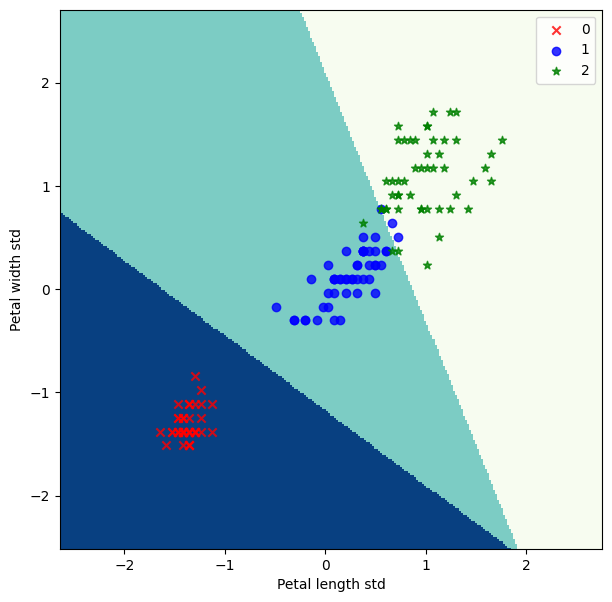

In [ ]:
lr = LogisticRegression(C=1000.0,random_state=2018) #  random_state is useful if you want reproducible results
lr.fit(X_train_std, y_train)
printing_db(X=X_combined_std, y=y_combined, model=lr)

In [ ]:
C_param = [0.001,0.01,0.1,1,10,100,1000,10000]

In [ ]:
def printing_db_1(X, y, model):
    markers = ['x','o','*']
    colors = ['red','blue','green']
    cmap = ListedColormap(colors[:len(np.unique(y))])
    res = 0.02
    #Plot regions
    x1min, x1max = X[:,0].min() -1, X[:,0].max() + 1
    x2min, x2max = X[:,1].min() -1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x1min,x1max,res),np.arange(x2min,x2max,res))

    output = model.predict(np.array([xx.ravel(), yy.ravel()]).T)
    output = output.reshape(xx.shape)
    plt.pcolormesh(xx,yy, output, cmap=plt.cm.GnBu_r)

    #PLOT ALL SAMPLES
    for index, item in enumerate(np.unique(y)):
        plt.scatter(x=X[y == item, 0], y=X[y == item, 1],alpha=0.8, c=cmap(index),
        marker=markers[index], label=item)

In [ ]:
plt.figure(figsize=(12, 12))

for idx, param in enumerate(C_param):
    
    lr = LogisticRegression(C = param, random_state = 2018)
    lr.fit(X_train_std,y_train)
    
    # Printing decision regions
    plt.subplot(4,2,idx+1)
    plt.subplots_adjust(hspace = 0.4)
    printing_db_1(X = X_combined_std
                      , y = y_combined
                      , model = lr)
    plt.xlabel('Petal length')
    plt.ylabel('Petal width')
    plt.title('C = %s'%param)
plt.show()    

## Conclusion: Small C values will increase the regularization strenght which implies the creation of simple models that tend to underfit the data. By using bigger C values, the model can increase it's complexity and adjust better to the data but with higher C values the model tends to overfit the data.

## References:

https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.meshgrid.html

https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.pcolormesh.html